# EDA and Visualizaitons

**Goal** Understand the customers visually who they are , how they spend , which campaings workded and most 
importantly who reponds and why ?

The questions we will answer:
1. Who is our typical customer? (Demographics)
2. Which campaigns performed best?
3. What do customers spend on?
4. Which channel do they prefer to buy from?
5. What separates a customer who responds from one who doesn't?
6. Does loyalty (how long they've been with us) affect response?

In [2]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #pandas and seaborn somethimes throuw harmless verison warnings . 

In [3]:
#Clean visual systle no cluster 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

In [4]:
#load the clean dataset 

data =pd.read_csv("../data/marketing_campaign_clean.csv")
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Days_Customer,Total_Spend,Total_Purchases,Total_Campaigns_Accepted,Has_Children
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,1,67,4867,1617,25,0,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,70,4317,27,6,0,1
2,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,40,4343,53,8,0,1
3,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,43,4365,422,19,0,1
4,Graduation,Divorced,55635.0,0,1,34,235,65,164,50,...,0,0,0,0,53,4797,590,21,0,1


# 1. Who is our Typical Cutomers ?
- `Age`            → How old are they?
- `Income`         → How much do they earn?
- `Education`      → What is their education level?
- `Marital_Status` → What is their family situation?

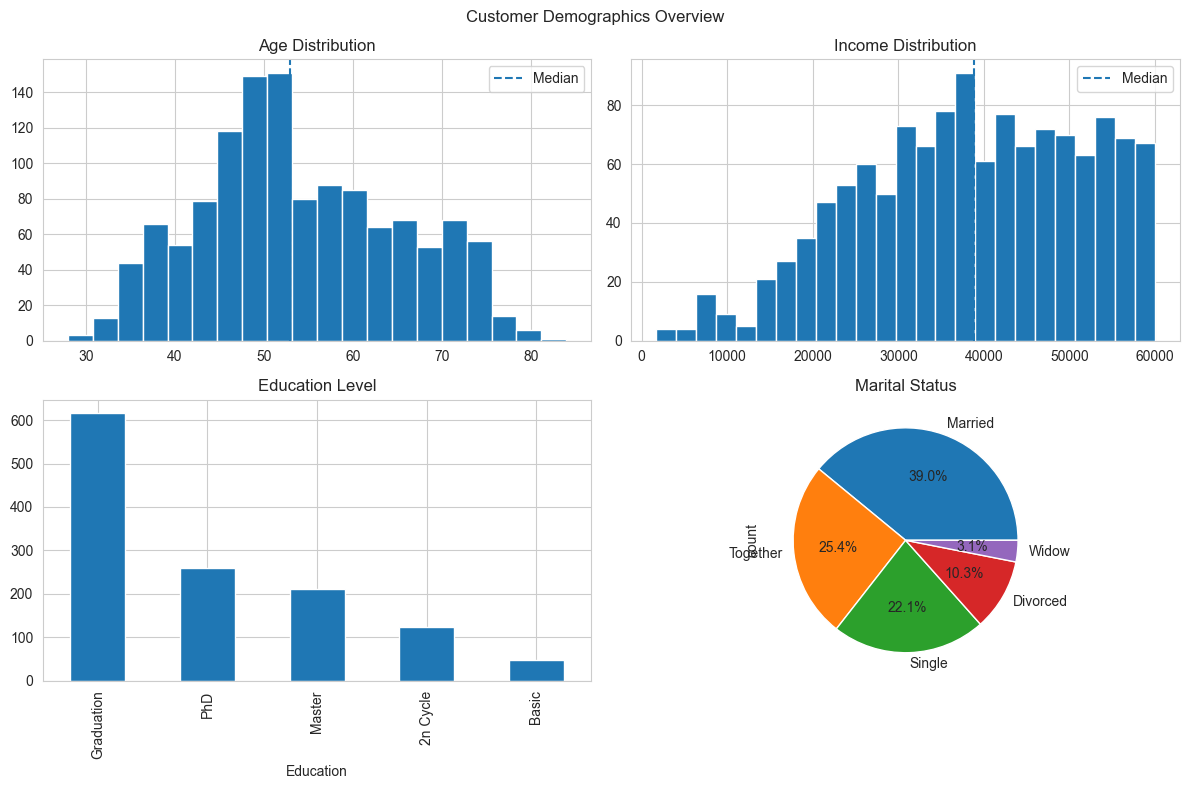

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Customer Demographics Overview")

# Age
axes[0, 0].hist(data['Age'], bins=20)
axes[0, 0].axvline(data['Age'].median(), linestyle='--', label='Median')
axes[0, 0].set_title("Age Distribution")
axes[0, 0].legend()

# Income
axes[0, 1].hist(data['Income'], bins=25)
axes[0, 1].axvline(data['Income'].median(), linestyle='--', label='Median')
axes[0, 1].set_title("Income Distribution")
axes[0, 1].legend()

# Education
data['Education'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title("Education Level")

# Marital Status
data['Marital_Status'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
axes[1, 1].set_title("Marital Status")

plt.tight_layout()
plt.show()

## What Each Chart Tells Us

### 1A Age
Median age is **54 years**. Most customers are between 40–65.
This is a mature audience not young, impulsive buyers.
**→ Campaigns should feel trustworthy and value-focused, not trendy.**

### 1B Income
Median income is around **$51,000**.
The chart is right-skewed — a small wealthy group pulls the tail right.
Two segments exist: the middle-income majority and a high-earning minority.
**→ Don't price campaigns the same for everyone. The wealthy tail buys premium without needing a discount.**

### 1C Education
Over **1,100 customers are Graduates** — more than half.
PhD and Master holders are next. Very few have basic education.
**→ This audience reads carefully. Well-written, informative campaigns beat flashy ones.**

### 1D Marital Status
**Married (38.7%) + Together (25.9%) = 64.6%** are in partnerships.
Most purchasing decisions involve two people.
**→ Campaigns framed around shared experiences will land better than solo-focused messaging.**

### The Typical Customer — In One Sentence

> A **54-year-old married graduate** earning around **$51,000** a year —
> thoughtful, value-conscious, and likely in a partnership.

# Which Campagins performed best ?


We ran 5 campaigns + 1 final offer (Response).
Each is a binary column — 1 = accepted, 0 = rejected.

**What we want to know:**
- Which campaign got the most people to say yes?
- How many customers said yes to multiple campaigns?

**Chart type logic:**
- Acceptance rate per campaign → Bar chart (comparing categories)
- How many campaigns per customer → Bar chart (counting frequency)

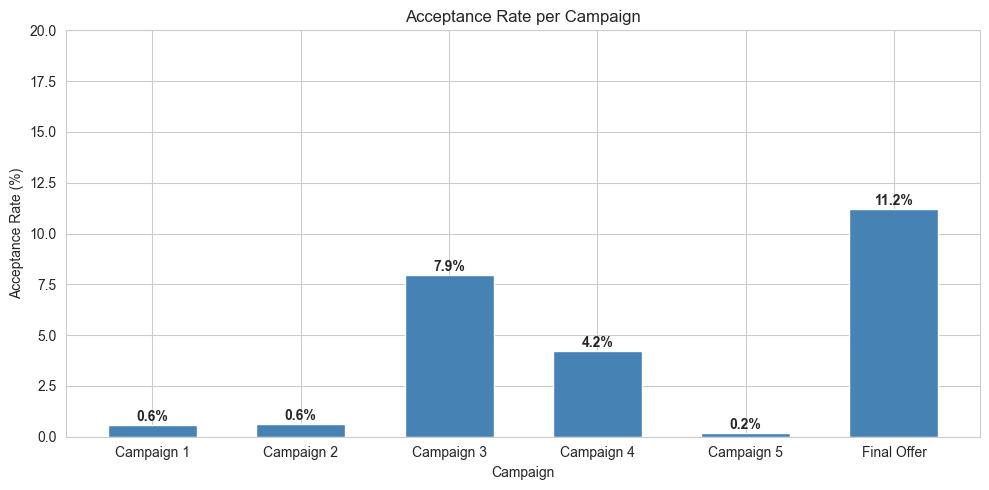

In [6]:
# ── Question: Which campaign got the best response? ──

# Calculate acceptance rate for each campaign
camp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']
camp_labels = ['Campaign 1', 'Campaign 2', 'Campaign 3',
            'Campaign 4', 'Campaign 5', 'Final Offer']

acceptance_rates = [data[col].mean() * 100 for col in camp_cols]

plt.figure(figsize=(10, 5))
bars = plt.bar(camp_labels, acceptance_rates,
            color='steelblue', edgecolor='white', width=0.6)

# Add percentage label on top of each bar
for bar, rate in zip(bars, acceptance_rates):
    plt.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{rate:.1f}%',
            ha='center', fontweight='bold', fontsize=10)

plt.title('Acceptance Rate per Campaign')
plt.xlabel('Campaign')
plt.ylabel('Acceptance Rate (%)')
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

##### Campagin 1 and campagin 2 flatin4ed at 0.6% something went seriously wrong . might be wrong audience , wrong timing , wrong messages which need further investigation

##### Campagin 3 and Campagin 4 made a progress then last campagin with good cutomer acceptance . customer were engaged in this campagin this campagin might be inresting and self benefit 

##### Final Offer doubled every prvious campagins at 11.2% . might be because of something specail in this campagin 

# How many Campaings did each customer Accepted ?

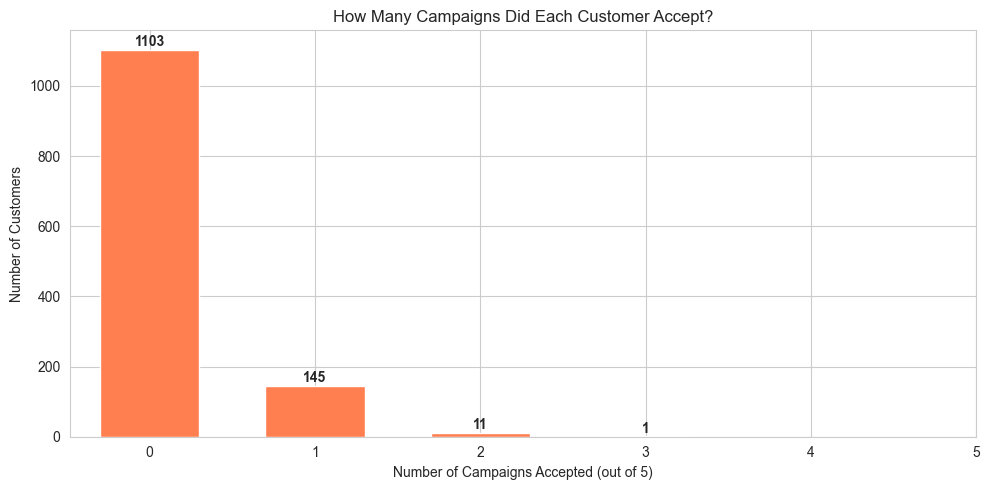

In [7]:
#  Are customers accepting one campaign or many? 

campaign_counts = data['Total_Campaigns_Accepted'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(campaign_counts.index, campaign_counts.values,
               color='coral', edgecolor='white', width=0.6)

# Add count label on top of each bar
for bar in bars:
     plt.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + 10,
               str(int(bar.get_height())),
               ha='center', fontweight='bold', fontsize=10)

plt.title('How Many Campaigns Did Each Customer Accept?')
plt.xlabel('Number of Campaigns Accepted (out of 5)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1, 2, 3, 4, 5])
plt.savefig("../Figures/How many campagins did each customer Accepted")
plt.tight_layout()
plt.show()

5 campaign were ran where 1 Was final Offer (respones )

**1 = Accepted** / **0 = Rejected** Campaings

A large majority of customers over 1,700 individuals did not respond to any campaign.
Only a small segment engaged with two or more campaigns.

This indicates a highly skewed engagement pattern, where a small group of customers drives most of the responses consistent with the 80/20 principle.


- Customer who accepted 2 or more capagins are the VIP cusotmer who are totally ingaged in every campagin 

# What do Customers Spend on ?


In [8]:
data.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'Days_Customer', 'Total_Spend',
       'Total_Purchases', 'Total_Campaigns_Accepted', 'Has_Children'],
      dtype='object')

##### we have 6 product spending columns
'MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntGoldProds',

 **What we want to know:**
- Which product category earns the most money?
- Do campaign responders spend more than non-responders?


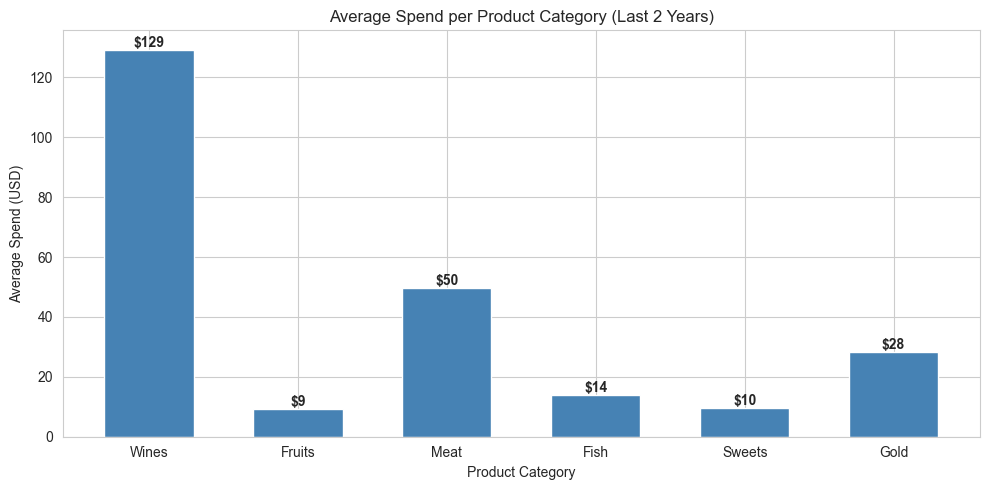

In [9]:
#  Which product makes the most money? ──

spend_cols  = ['MntWines', 'MntFruits', 'MntMeatProducts',
               'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cat_labels  = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

avg_spend = [data[col].mean() for col in spend_cols]

plt.figure(figsize=(10, 5))
bars = plt.bar(cat_labels, avg_spend,
               color='steelblue', edgecolor='white', width=0.6)

# Add dollar label on top of each bar
for bar, val in zip(bars, avg_spend):
     plt.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + 1,
               f'${val:.0f}',
               ha='center', fontweight='bold', fontsize=10)

plt.title('Average Spend per Product Category (Last 2 Years)')
plt.xlabel('Product Category')
plt.ylabel('Average Spend (USD)')
plt.tight_layout()
plt.savefig("../Figures/Average spend per product catg")

plt.show()

# Which Channel do customers prefer to buy from ?


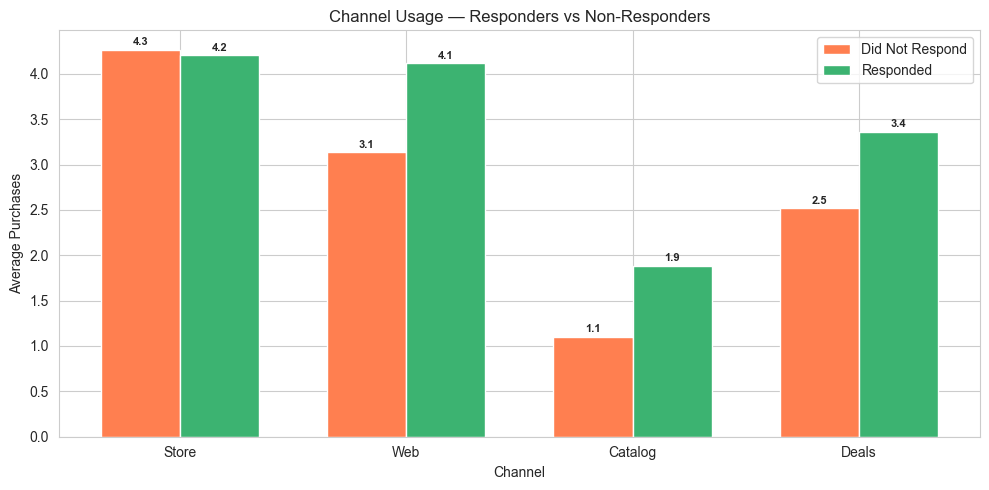

In [10]:
# ── Question: Do responders shop differently by channel? ──

channel_cols   = ['NumStorePurchases', 'NumWebPurchases',
                  'NumCatalogPurchases', 'NumDealsPurchases']
channel_labels = ['Store', 'Web', 'Catalog', 'Deals']

# Average purchases per channel for each group
resp_avg   = [data[data['Response'] == 1][col].mean() for col in channel_cols]
noresp_avg = [data[data['Response'] == 0][col].mean() for col in channel_cols]

x = range(len(channel_labels))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar([i - width/2 for i in x], noresp_avg, width,
                label='Did Not Respond', color='coral',   edgecolor='white')
bars2 = plt.bar([i + width/2 for i in x], resp_avg,   width,
                label='Responded',       color='mediumseagreen', edgecolor='white')

# Add value labels
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.1f}',
             ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.1f}',
             ha='center', fontsize=8, fontweight='bold')

plt.title('Channel Usage — Responders vs Non-Responders')
plt.xlabel('Channel')
plt.ylabel('Average Purchases')
plt.xticks(list(x), channel_labels)
plt.legend()
plt.tight_layout()
plt.show()